In [ ]:
import pandas as pd
pat1 = path+"/HateSpeechDataset.csv"

df = pd.read_csv(pat1)
df

,Content,Label,Content_int
0,denial of normal the con be asked to comment on tragedies an emotional retard,1,"[146715, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 146714]"
1,just by being able to tweet this insufferable bullshit proves trump a nazi you vagina,1,"[146715, 14, 15, 16, 17, 7, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 146714]"
2,that is retarded you too cute to be single that is life,1,"[146715, 28, 29, 30, 26, 31, 32, 7, 5, 33, 28, 29, 34, 146714]"
3,thought of a real badass mongol style declaration of war the attackers capture a citizen of the soon to be,1,"[146715, 35, 1, 24, 36, 37, 38, 39, 40, 1, 41, 3, 42, 43, 24, 44, 1, 3, 45, 7, 5, 146714]"
4,afro american basho,1,"[146715, 46, 47, 48, 146714]"
...,...,...,...
440901,crash another movie from left field i have to ask why did star wars episode iii even got nominated people go to see movies like those at,0,"[146715, 1780, 649, 1673, 347, 701, 1702, 80, 87, 7, 919, 186, 209, 1888, 6430, 1651, 12886, 418, 113, 16292, 216, 135, 7, 817, 1902, 109, 343, 236, 146714]"
440902,i why do not you debate first before starting an edit war,0,"[146715, 80, 186, 340, 76, 26, 6407, 566, 2608, 5505, 11, 4669, 41, 146714]"
440903,removal of i reverted the removal of the above section i believe it is very misguided to remove this because the transit explanation is so widespread and frequently authoritatively presented it is wrong and it is important to say so if whatever do not say so explicitly whatever are tacitly givin...,0,"[146715, 18731, 1, 80, 48182, 3, 18731, 1, 3, 3913, 1956, 80, 656, 63, 29, 276, 19252, 7, 883, 19, 122, 3, 13116, 2747, 29, 97, 14422, 111, 7273, 76964, 12542, 63, 29, 1145, 111, 63, 29, 2659, 7, 107, 97, 204, 220, 340, 76, 107, 97, 4738, 220, 154, 35245, 747, 63, 26818, 167, 1980, 1251, 7, 19, ..."
440904,i have unblocked you eddie as i discussed on user talkable accusing nile of assuming bad faith regarding yourself is a hair s breadth away from assuming bad faith regarding nile himself watch it nsle does not assume bad faith regarding you i believe he just thinks you have a knack for disruptive...,0,"[146715, 80, 87, 20515, 26, 10684, 273, 80, 9592, 9, 4236, 54281, 12969, 10338, 1, 2671, 1551, 2014, 4704, 1296, 29, 24, 1125, 140, 42822, 838, 347, 2671, 1551, 2014, 4704, 10338, 832, 586, 63, 69362, 124, 76, 659, 1551, 2014, 4704, 26, 80, 656, 191, 14, 1719, 26, 87, 24, 20873, 255, 8507, 22618..."


### Explanation: Data Loading
This cell loads the raw `HateSpeechDataset.csv` from the downloaded path into a Pandas DataFrame (`df`) and previews the first few rows to inspect the raw data.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("waalbannyantudre/hate-speech-detection-curated-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'hate-speech-detection-curated-dataset' dataset.
Path to dataset files: /kaggle/input/hate-speech-detection-curated-dataset


### Explanation: Downloading the Dataset
This cell uses the `kagglehub` library to search for and download the latest version of the "Hate Speech Detection" dataset directly from Kaggle into your environment.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440906 entries, 0 to 440905
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Content      440906 non-null  object
 1   Label        440906 non-null  object
 2   Content_int  440906 non-null  object
dtypes: object(3)
memory usage: 10.1+ MB


### Explanation: Dataset Information
Calling `df.info()` displays an overview of the DataFrame, including the column names, data types, and count of non-null values for each column.

In [ ]:
df.isnull().sum(

)

,0
Content,0
Label,0
Content_int,0


### Explanation: Checking for Missing Values
This cell checks each column in the DataFrame for missing (`null`) values and displays the total missing count per column.

In [ ]:
df["Label"].value_counts()

,count
Label,
0,361594
1,79305
Label,7


### Explanation: Label Frequency
This cell counts the frequency of each unique value in the `Label` column to assess the balance of target classes.

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

### Explanation: NLTK Setup
This cell downloads crucial resource packages (`punkt_tab` for tokenization and `stopwords` for text filtering) from the NLTK library.

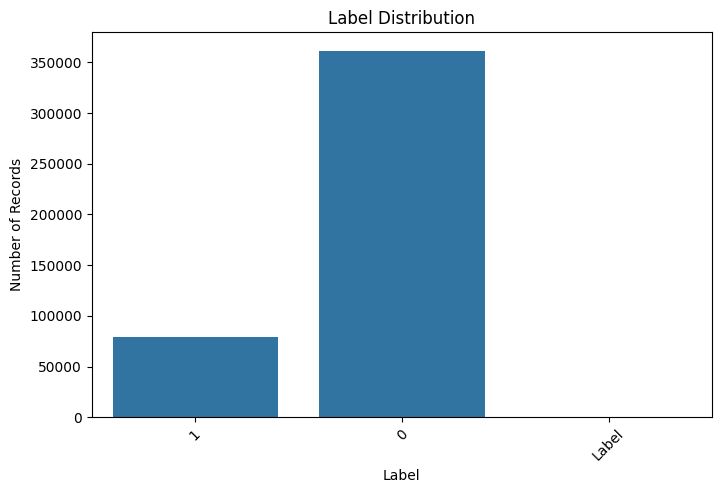

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Label"
)

plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)

plt.show()

### Explanation: Label Distribution Visualization
This cell generates a count plot using Seaborn to visually represent the number of occurrences of each target label.

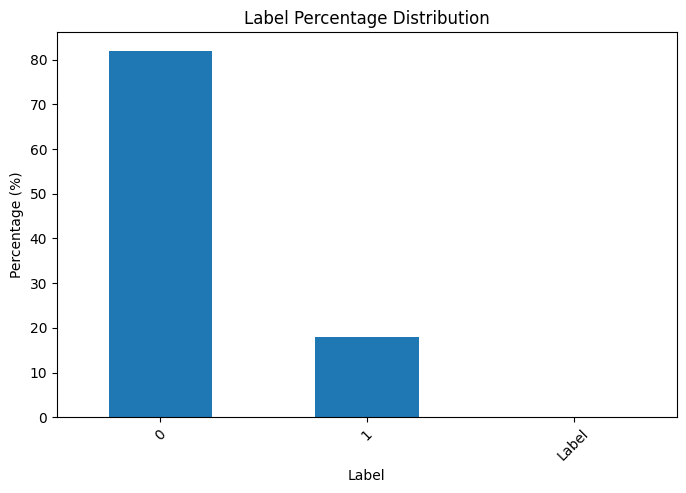

In [ ]:
label_percentage = df["Label"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))

label_percentage.plot(kind="bar")

plt.title("Label Percentage Distribution")
plt.xlabel("Label")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

### Explanation: Percentage Label Distribution
This cell calculates the relative percentage of each label and displays it in a bar chart to highlight class imbalance.

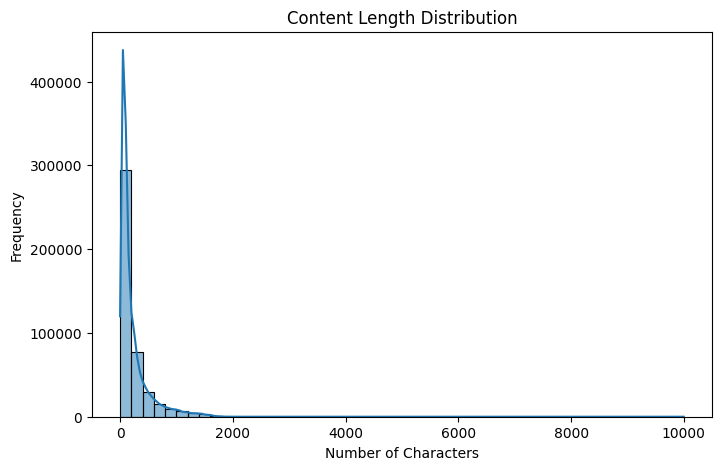

In [ ]:
df["content_length"] = df["Content"].astype(str).str.len()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="content_length",
    bins=50,
    kde=True
)

plt.title("Content Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

### Explanation: Content Length Analysis
This cell measures the character length of each record's text and plots a histogram with a Kernel Density Estimate (KDE) to visualize text length distribution.

In [ ]:
# Reload the dataset to get the original data back
df = pd.read_csv(pat1)

# Convert Label column to numeric, forcing non-numeric values (like text headers) to NaN, and drop them
df["Label"] = pd.to_numeric(df["Label"], errors='coerce')
df = df.dropna(subset=["Label"])

# Label 0 aur baaki labels alag karo
df_0 = df[df["Label"] == 0]
df_other = df[df["Label"] != 0]

# Label 0 se 250,000 rows remove karo
df_0_reduced = df_0.sample(
    n=len(df_0) - 200000,
    random_state=42
)

# Combine
df = pd.concat([df_0_reduced, df_other])

# Shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check
print(df.shape)
print(df["Label"].value_counts())

(240899, 3)
Label
0.0    161594
1.0     79305
Name: count, dtype: int64


### Explanation: Class Balancing / Downsampling
This cell removes non-numeric label noise, drops missing targets, and balances the dataset by randomly downsampling 200,000 instances of class `0` (the majority class) to prevent model bias.

       Before   After
Label                
0.0    361594  161594
1.0     79305   79305


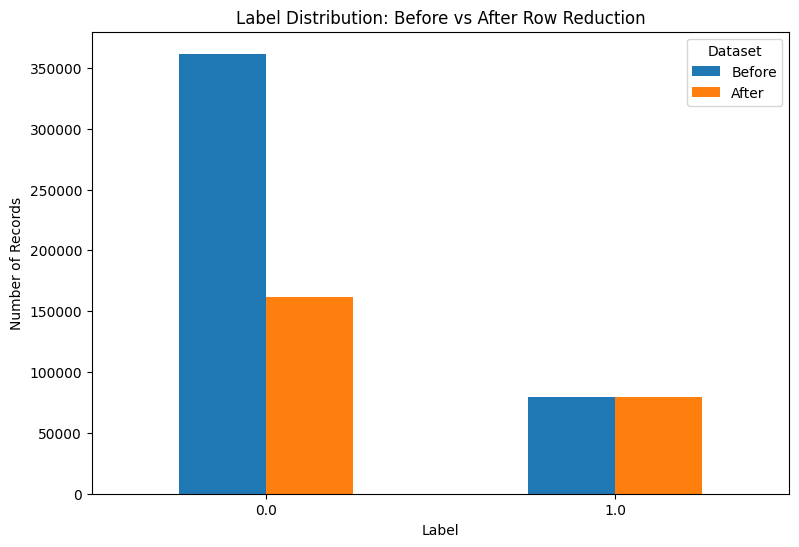

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load original dataset as df_original
df_original = pd.read_csv(pat1)
df_original["Label"] = pd.to_numeric(df_original["Label"], errors='coerce')
df_original = df_original.dropna(subset=["Label"])

# Original counts
before = df_original["Label"].value_counts().sort_index()

# Current dataframe counts
after = df["Label"].value_counts().sort_index()

# Comparison DataFrame
comparison = pd.DataFrame({
    "Before": before,
    "After": after
}).fillna(0)

print(comparison)

# Graph
comparison.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Label Distribution: Before vs After Row Reduction")
plt.xlabel("Label")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Dataset")

plt.show()

### Explanation: Before vs After Reduction Comparison
This cell compares and plots the label frequencies before and after downsampling to verify the changes visually.

In [ ]:

import re
#5. Text Cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['Content'].apply(clean_text)

### Explanation: Text Cleaning Function
This cell defines a utility function that converts text to lowercase and removes all non-alphabetical characters (such as numbers and punctuation) using regular expressions.

In [ ]:
#tokenization
from nltk.tokenize import word_tokenize
df["tokens"]=df["clean_text"].apply(word_tokenize)

### Explanation: Tokenization
This cell splits the cleaned text strings into lists of individual words (tokens) using NLTK's `word_tokenize` function.

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

df["Content"] = df["Content"].apply(
    lambda text: " ".join(
        word for word in text.split()
        if word not in stop_words
    )
)

print(df[["Content_int"]].head(10))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                                                                                                                                                                     Content_int
0                                                                                                                       [146715, 19, 905, 1850, 7, 214, 63, 157, 3357, 694, 14188, 26, 1428, 9, 72, 570, 146714]
1                                                                                         [146715, 80, 165, 1071, 216, 154, 1558, 298, 85, 2733, 7, 16159, 2696, 347, 639, 36, 5273, 7, 16847, 349, 139, 146714]
2                                                                                                                                                               [146715, 10741, 481, 29, 24, 1906, 4569, 146714]
3  [146715, 134, 28624, 26, 154, 28625, 5262, 26, 3119, 2804, 135, 1092, 119, 15283, 608, 89, 5305, 1792, 285, 608, 285, 608, 608, 89, 5305, 1792, 9936, 608, 89, 45

### Explanation: Stopword Removal
This cell filters out common English stopwords (like 'is', 'the', 'and') from the text to ensure the model focuses on content-carrying words.

In [ ]:
import sys
from nltk.stem import PorterStemmer

# Increase recursion depth limit just in case
sys.setrecursionlimit(5000)

stemmer = PorterStemmer()

# We stem only words with reasonable lengths to avoid triggering the NLTK recursion bug
def safe_stem(text):
    words = str(text).split()
    stemmed_words = []
    for word in words:
        if len(word) < 50:  # Normal words are rarely over 50 characters
            stemmed_words.append(stemmer.stem(word))
        else:
            stemmed_words.append(word)  # Keep extremely long sequences as-is
    return " ".join(stemmed_words)

df["stemmed_text"] = df["clean_text"].apply(safe_stem)
print(df[["clean_text", "stemmed_text"]].head(10))

                                                                                                                                                                                                           clean_text  \
0                                                                                                                                             this guy seems to get it but otherwise sorry jigs you reply on your own   
1                                                                                                   i heard black people are doing all these marches to divert attention from their real plan to dominate our country   
2                                                                                                                                                                                   boris johnson is a national shame   
3  man snotbarryroux you are goggle due you dig information go ahead oh flake face with rolling eyes thinking face thinking face fac

### Explanation: Stemming
This cell applies Porter's Stemming algorithm to reduce words to their base form (e.g., 'running' to 'run'). It contains safety limits on word lengths to prevent recursive overflow errors.

In [ ]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

df["lemmatized_text"] = df["Content"].apply(
    lambda text: " ".join(
        lemmatizer.lemmatize(word)
        for word in text.split()
    )
)

print(df[["Content", "lemmatized_text"]].head(10))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


                                                                                                                                                                              Content  \
0                                                                                                                                            guy seems get otherwise sorry jigs reply   
1                                                                                                              heard black people marches divert attention real plan dominate country   
2                                                                                                                                                        boris johnson national shame   
3  man snotbarryroux goggle due dig information go ahead oh flake face rolling eyes thinking face thinking face face rolling eyes beaming face smiling eyes beaming face smiling eyes   
4                                                                          

### Explanation: Lemmatization
This cell applies WordNet Lemmatization to convert words back to their dictionary root form (lemmas), which is often more accurate than simple stemming.

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download("wordnet")
lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda x: [lemmatizer.lemmatize(word) for word in x]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Explanation: Token-Level Lemmatization
This cell applies WordNet Lemmatization on the tokenized word lists (`df['tokens']`) for granular processing.

In [ ]:
# Convert Text to Numerical Features
#Bag of Words (BoW)
from sklearn.feature_extraction.text import CountVectorizer

# Join the list of lemmatized/stemmed tokens back into clean sentences
df['processed_text'] = df['tokens'].apply(lambda x: ' '.join(x))

cv = CountVectorizer()

X = cv.fit_transform(df['processed_text'])

### Explanation: Bag of Words Vectorization
This cell converts the processed text into numerical vectors using a simple occurrence-counting approach via `CountVectorizer`.

In [ ]:
from sklearn.model_selection import train_test_split

# Tokens ko text me convert
df["final_text"] = df["tokens"].apply(
    lambda x: " ".join(x)
)

# Input and target
X = df["final_text"]
y = df["Label"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


### Explanation: Train-Test Split
This cell reconstructs clean sentences from the processed tokens and splits the dataset into Training (80%) and Testing (20%) sets using stratified sampling to maintain class proportions.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['processed_text'])

### Explanation: TF-IDF Feature Extraction
This cell calculates the TF-IDF (Term Frequency-Inverse Document Frequency) matrix, weighing terms by how unique and informative they are across the dataset.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Label'])

### Explanation: Target Label Encoding
This cell encodes categorical target labels into standardized numerical indices using `LabelEncoder`.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Initialize the vectorizer
tfidf = TfidfVectorizer()

# 2. Transform the text data into numerical features
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 3. Fit the Naive Bayes model on the numerical features
model = MultinomialNB()
model.fit(X_train_vec, y_train)



MultinomialNB()

### Explanation: Model Training
This cell transforms training and testing texts into TF-IDF vectors, and fits a Multinomial Naive Bayes classifier on the training data.

In [ ]:
# Transform X_test using our fitted tfidf vectorizer first
X_test_vec = tfidf.transform(X_test)

# Make predictions using the vectorized data
y_pred = model.predict(X_test_vec)

### Explanation: Model Predictions
This cell transforms the test feature set to match the vectorizer space and uses the trained Naive Bayes model to make class predictions.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7939601494396015
              precision    recall  f1-score   support

         0.0       0.80      0.92      0.86     32319
         1.0       0.76      0.54      0.63     15861

    accuracy                           0.79     48180
   macro avg       0.78      0.73      0.75     48180
weighted avg       0.79      0.79      0.78     48180



### Explanation: Model Evaluation Metrics
This cell prints the overall test accuracy and a comprehensive classification report containing Precision, Recall, and F1-scores for each class.

In [ ]:
sample = ["that is retarded you too cute to be single tha"]

sample_vector = tfidf.transform(sample)

prediction = model.predict(sample_vector)

# Cast prediction to int to avoid dtype('float64') to dtype('int64') TypeError during inverse_transform
print(le.inverse_transform(prediction.astype(int)))

[1.]


### Explanation: Single Instance Inference
This cell tests the trained model with a custom text sample, vectorizing it and decoding the numerical output label back to its original class representation.

In [ ]:
import pandas as pd
import os

pd.set_option('display.max_colwidth', 300)

# Ensure the dataset path and df are defined
pat1 = os.path.join(path, "HateSpeechDataset.csv")

if 'df' not in locals():
    print("Loading and preparing df...")
    df = pd.read_csv(pat1)
    # Convert Label column to numeric, forcing non-numeric values to NaN, and drop them
    df["Label"] = pd.to_numeric(df["Label"], errors='coerce')
    df = df.dropna(subset=["Label"])

    # Downsample class 0 to match previous reduction
    df_0 = df[df["Label"] == 0]
    df_other = df[df["Label"] != 0]
    df_0_reduced = df_0.sample(n=len(df_0) - 200000, random_state=42)
    df = pd.concat([df_0_reduced, df_other]).sample(frac=1, random_state=42).reset_index(drop=True)

# Safely display the sample
print(df[['Content', 'Label']].sample(10, random_state=42))

                                                                                                                                                                                                                                                                                                            Content  \
163229               biographies wikipedia pass notability guidelines reliable source references case article qualified deleted per criteria slut therefore deleted would leave note talk page deleting use article wizard help create article create one sandbox address references move main space leisure cheers   
165282  belated welcome wishing belated welcome wikipedia lynnanchio see already around wanted thank though seem successful finding around benefit following links help editors get wikipedia introduction five pillars wikipedia edit page help pages write great article editor index wikipedia also post talk...   
145408                                                             

### Explanation: Dataset Sampling and Inspection
This cell ensures proper configuration of dataset variables and randomly prints 10 sample sentences with their labels to verify consistency.

In [ ]:
import joblib

# Model save
joblib.dump(model, "naive_bayes_model.joblib")

# TF-IDF vectorizer save
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

# Label Encoder save
joblib.dump(le, "label_encoder.joblib")

print("Model, TF-IDF and Label Encoder saved successfully!")

Model, TF-IDF and Label Encoder saved successfully!


### Explanation: Saving Pipeline Artifacts
This cell saves the trained Naive Bayes classifier model, the TF-IDF vectorizer, and the Label Encoder as binary `.joblib` files to allow for future deployment or reuse without retraining.